# Improved Model
- Added a preprocess input: convert everything between [-1, +1]
- Applied data_augmentation
- Decreased the Learning rate of optimizer
- Increased the number of epochs

# Step 1: Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Step 2: Load Dataset
- since I have 90 images of each (approx) in training, I will keep batch size small (8)

In [2]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "temp/data_cats_dogs_small/train",
    image_size=(224, 224),
    batch_size=4,
    shuffle=True 
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "temp/data_cats_dogs_small/val",
    image_size=(224, 224),
    batch_size=4,
    shuffle=True 
)

Found 180 files belonging to 2 classes.
Found 69 files belonging to 2 classes.


In [3]:
# Lets see 1 image
for images, labels in train_data.take(1):
    img = images[0]   # first image in batch
    label = labels[0]

print(img.numpy())

[[[ 76.640625  214.82812   240.73438  ]
  [ 74.09424   214.09424   239.65674  ]
  [ 69.875     211.75      238.28125  ]
  ...
  [ 94.33252   214.33252   238.80127  ]
  [ 93.92383   211.04883   235.76758  ]
  [100.953125  216.95312   241.95312  ]]

 [[ 74.09473   212.25      238.17236  ]
  [ 71.02832   210.78125   236.46729  ]
  [ 67.16113   208.79443   235.40625  ]
  ...
  [ 90.50488   210.66602   235.0542   ]
  [ 90.04932   207.54492   232.14014  ]
  [ 97.89014   213.93848   238.92236  ]]

 [[ 79.71875   217.71875   243.71875  ]
  [ 77.6875    216.25      242.53125  ]
  [ 73.40625   213.875     240.875    ]
  ...
  [ 74.16553   195.10303   219.10303  ]
  [ 83.32422   202.60547   226.60547  ]
  [ 94.42871   213.30127   237.34375  ]]

 ...

 [[ 11.910645  195.67627   223.77002  ]
  [  9.846191  193.61182   221.70557  ]
  [  8.178223  191.94385   220.0376   ]
  ...
  [  3.5063477 193.53125   219.53125  ]
  [  3.2680664 194.        221.4375   ]
  [  3.        194.        222.       ]]

 [

In [4]:
# preprocess input: convert everything between [-1, +1]

train_data = train_data.map(lambda x, y: (preprocess_input(x), y))
val_data = val_data.map(lambda x, y: (preprocess_input(x), y))

In [5]:
for images, labels in train_data.take(1):
    img = images[0]   # first image in batch
    label = labels[0]

print(img.numpy())

[[[ 0.7441807   0.5861275   0.48054266]
  [ 0.6760887   0.60922945  0.47465312]
  [ 0.5960088   0.6135858   0.4675424 ]
  ...
  [-0.47746885 -0.6343316  -0.7206061 ]
  [-0.5346261  -0.69148886 -0.7777633 ]
  [-0.51161754 -0.6684803  -0.7547548 ]]

 [[ 0.7302424   0.5721891   0.46660447]
  [ 0.6878346   0.6209754   0.48639894]
  [ 0.5921569   0.60973394  0.4636904 ]
  ...
  [-0.49366337 -0.65052617 -0.7368007 ]
  [-0.5270388  -0.68390155 -0.77017605]
  [-0.4870237  -0.64388645 -0.73016095]]

 [[ 0.7139194   0.55586624  0.45028138]
  [ 0.7003113   0.63345206  0.49887574]
  [ 0.5878719   0.60544896  0.45940554]
  ...
  [-0.4857316  -0.64259434 -0.72886884]
  [-0.5250515  -0.6819142  -0.7681887 ]
  [-0.48723662 -0.64409935 -0.73037386]]

 ...

 [[-0.08015066 -0.11152321 -0.20564085]
  [-0.16579366 -0.1971662  -0.2912839 ]
  [-0.4234866  -0.447016   -0.56466305]
  ...
  [ 0.29932034  0.28363407  0.10324192]
  [ 0.22890496  0.21321869  0.03282654]
  [ 0.25390387  0.23821759  0.05782545]]

 [

# Step 3: Load Pretrained Model

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


# step4: Freeze Base Model

In [7]:
base_model.trainable = False

# Step 5: Add Custom Layers

In [8]:
# Added this
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

In [9]:
model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2, activation='softmax')
])


# Step 6: Compile Model

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # made learning rate smaller
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Step 7: Train

In [11]:
# increased training epochs from 8 to 16

history = model.fit(train_data, validation_data=val_data, epochs=16)

Epoch 1/16


45/45 [==============================] - 13s 149ms/step - loss: 0.4586 - accuracy: 0.7944 - val_loss: 0.2488 - val_accuracy: 0.9275
Epoch 2/16
45/45 [==============================] - 5s 108ms/step - loss: 0.2073 - accuracy: 0.9333 - val_loss: 0.1753 - val_accuracy: 0.9565
Epoch 3/16
45/45 [==============================] - 5s 107ms/step - loss: 0.1260 - accuracy: 0.9833 - val_loss: 0.1225 - val_accuracy: 0.9710
Epoch 4/16
45/45 [==============================] - 5s 107ms/step - loss: 0.1387 - accuracy: 0.9500 - val_loss: 0.1185 - val_accuracy: 0.9710
Epoch 5/16
45/45 [==============================] - 5s 105ms/step - loss: 0.1075 - accuracy: 0.9722 - val_loss: 0.0809 - val_accuracy: 0.9710
Epoch 6/16
45/45 [==============================] - 5s 108ms/step - loss: 0.0994 - accuracy: 0.9778 - val_loss: 0.0805 - val_accuracy: 0.9710
Epoch 7/16
45/45 [==============================] - 5s 107ms/step - loss: 0.0785 - accuracy: 0.9667 - val_loss: 0.0700 - val_accuracy: 0.9710
Epo

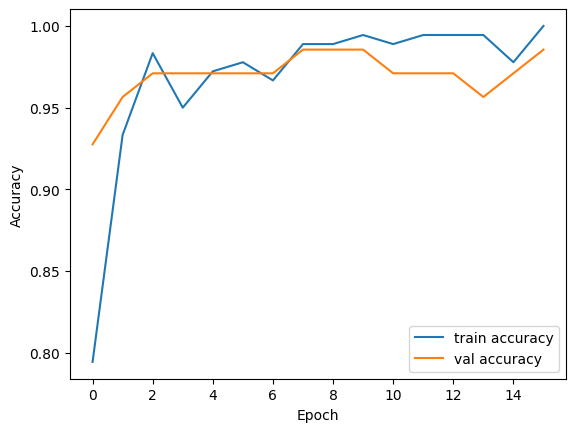

In [14]:
# Plot Training Accuracy and Loss
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Lets test on few images
- pic1 pic2 pic3 pic4

In [15]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

img_path = "pic4.jpg" # pic1 , pic2, pic3 , pic4

# -------- 1. LOAD IMAGE --------
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

# -------- 2. PREPROCESS (IMPORTANT FIX) --------
img_array = preprocess_input(img_array)   # ✅ instead of /255

# -------- 3. ADD BATCH DIM --------
img_array = np.expand_dims(img_array, axis=0)

# -------- 4. PREDICT --------
prediction = model.predict(img_array)

# -------- 5. INTERPRET --------
class_names = ['cats', 'dogs']  # must match training

pred_idx = np.argmax(prediction, axis=1)[0]
confidence = np.max(prediction)

print("Raw Prediction:", prediction)
print(f"Predicted: {class_names[pred_idx]} ({confidence:.2f})")


1/1 [==============================] - 1s 1s/step
Raw Prediction: [[0.00277795 0.99722207]]
Predicted: dogs (1.00)


In [16]:
class_names = ["cat", "dog"]  # VERY IMPORTANT: same order as training

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print(f"Prediction: {predicted_class}")
print(f"Confidence: {confidence:.2f}")

Prediction: dog
Confidence: 1.00


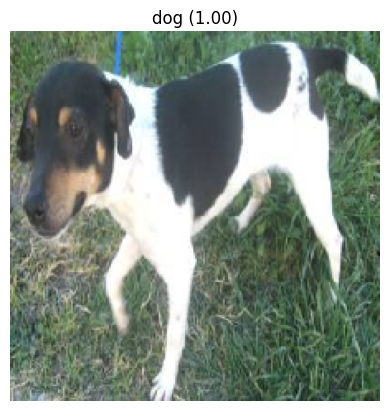

In [17]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f})")
plt.axis('off')
plt.show()


# Lets do above on images in test directory

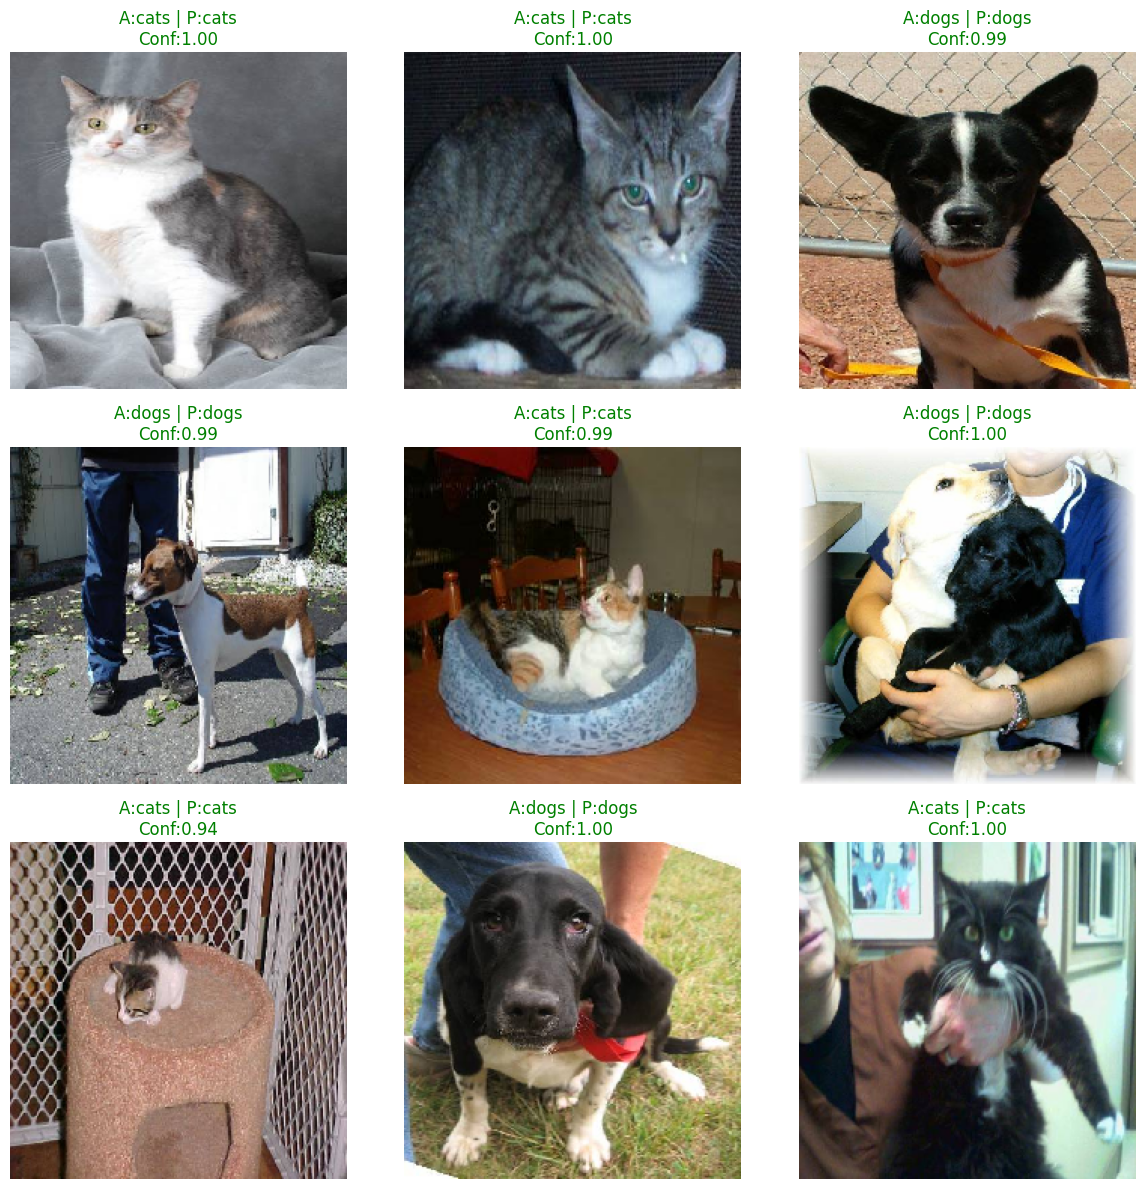

In [18]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

class_names = ['cats', 'dogs']  # or saved earlier

test_dir = "temp/data_cats_dogs_small/test"
# class_names = train_data.class_names  # should be ['cats', 'dogs']

files = [f for f in os.listdir(test_dir) if f.endswith(".jpg")]

# pick random 9 images
random_files = random.sample(files, 9)

plt.figure(figsize=(12, 12))

for i, file in enumerate(random_files):
    img_path = os.path.join(test_dir, file)

    # -------- 1. TRUE LABEL (robust) --------
    actual_idx = 0 if "cat" in file.lower() else 1
    actual = class_names[actual_idx]

    # -------- 2. LOAD IMAGE --------
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    # -------- 3. PREPROCESS --------
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # -------- 4. PREDICT --------
    pred = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(pred, axis=1)[0]   # FIXED
    confidence = np.max(pred)

    predicted = class_names[pred_idx]

    # -------- 5. COLOR FOR CORRECT/WRONG --------
    color = "green" if pred_idx == actual_idx else "red"

    # -------- 6. PLOT --------
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(f"A:{actual} | P:{predicted}\nConf:{confidence:.2f}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()


# Check accuracy

In [19]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

y_true = []
y_pred = []

class_names = ['cats', 'dogs']  # MUST match train_data.class_names

for file in files:
    if file.endswith(".jpg"):
        img_path = os.path.join(test_dir, file)

        # -------- 1. TRUE LABEL --------
        actual = 0 if "cat" in file.lower() else 1
        y_true.append(actual)

        # -------- 2. LOAD IMAGE --------
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)

        # IMPORTANT: same preprocessing as training
        img_array = preprocess_input(img_array)

        img_array = np.expand_dims(img_array, axis=0)

        # -------- 3. PREDICT --------
        pred = model.predict(img_array, verbose=0)

        predicted = np.argmax(pred, axis=1)[0]   # safer
        confidence = np.max(pred)

        y_pred.append(predicted)

        # -------- 4. DEBUG WRONG CASES --------
        if actual != predicted:
            print(f"   Wrong: {file}")
            print(f"   Actual: {class_names[actual]}")
            print(f"   Predicted: {class_names[predicted]}")
            print(f"   Confidence: {confidence:.2f}\n")

# -------- 5. FINAL ACCURACY --------
accuracy = np.mean(np.array(y_true) == np.array(y_pred))
print(f"Test Accuracy: {accuracy:.2f}")


✅ Test Accuracy: 1.00


# Plot confusion matrix

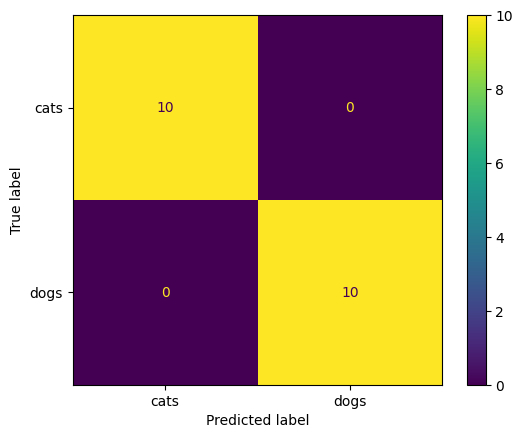

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.show()

# STOP